# Average Monthly Temperatures

## 1. Data Preparation

Generate a synthetic dataset of average monthly temperatures for 10 cities and convert it into a Pandas DataFrame.


In [1]:
import numpy as np
import pandas as pd

# Make the randomly generated values reproducible.
np.random.seed(42)

cities = [
    'New York', 'London', 'Tokyo', 'Paris', 'Sydney',
    'Cairo', 'Toronto', 'Mumbai', 'Berlin', 'Cape Town'
]

months = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Generate 12 monthly temperatures for each of the 10 cities.
temperature_data = np.random.uniform(
    low=-5,
    high=35,
    size=(len(cities), len(months))
)

# Convert the NumPy array into a labeled DataFrame.
temperature_df = pd.DataFrame(
    temperature_data,
    index=cities,
    columns=months
)
temperature_df.index.name = 'City'
temperature_df.columns.name = 'Month'

# Display temperatures rounded to one decimal place.
temperature_df.round(1)


Month,January,February,March,April,May,June,July,August,September,October,November,December
City,,,,,,,,,,,,
New York,10.0,33.0,24.3,18.9,1.2,1.2,-2.7,29.6,19.0,23.3,-4.2,33.8
London,28.3,3.5,2.3,2.3,7.2,16.0,12.3,6.6,19.5,0.6,6.7,9.7
Tokyo,13.2,26.4,3.0,15.6,18.7,-3.1,19.3,1.8,-2.4,33.0,33.6,27.3
Paris,7.2,-1.1,22.4,12.6,-0.1,14.8,-3.6,31.4,5.4,21.5,7.5,15.8
Sydney,16.9,2.4,33.8,26.0,32.6,30.8,18.9,31.9,-1.5,2.8,-3.2,8.0
Cairo,10.5,5.9,28.1,9.3,6.2,16.7,0.6,27.1,-2.0,34.5,25.9,2.9
Toronto,-4.8,27.6,23.3,24.2,25.9,-2.0,9.3,-0.4,29.5,19.9,8.2,-2.5
Mumbai,7.4,8.0,24.2,20.5,30.5,13.9,-0.2,23.5,25.4,17.5,25.8,14.8
Berlin,15.9,12.1,-4.0,-0.7,-3.7,20.5,7.6,15.3,31.3,5.0,11.4,25.2


## 2. Data Analysis

Calculate the annual average temperature for each city.


In [2]:
temperature_df.info()

<class 'pandas.DataFrame'>
Index: 10 entries, New York to Cape Town
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   January    10 non-null     float64
 1   February   10 non-null     float64
 2   March      10 non-null     float64
 3   April      10 non-null     float64
 4   May        10 non-null     float64
 5   June       10 non-null     float64
 6   July       10 non-null     float64
 7   August     10 non-null     float64
 8   September  10 non-null     float64
 9   October    10 non-null     float64
 10  November   10 non-null     float64
 11  December   10 non-null     float64
dtypes: float64(12)
memory usage: 1.1 KB


In [3]:
# Calculate the mean across the 12 month columns for each city.
annual_average_temperature = temperature_df.mean(axis=1)

annual_average_df = annual_average_temperature.to_frame(
    name='Annual Average Temperature (°C)'
)

annual_average_df.round(1)


,Annual Average Temperature (°C)
City,
New York,15.6
London,9.6
Tokyo,15.5
Paris,11.1
Sydney,16.6
Cairo,13.8
Toronto,13.2
Mumbai,17.6
Berlin,11.3


Find the city with the highest and lowest average temperature

In [4]:
avg_annual = annual_average_temperature.round(1)

hottest_city = avg_annual.idxmax()
highest_temperature = avg_annual.loc[hottest_city]

print(
    f"Highest annual average: {hottest_city} "
    f"({highest_temperature:.1f} °C)"
)


Highest annual average: Mumbai (17.6 °C)


In [5]:
coldest_city = avg_annual.idxmin()
lowest_temperature = avg_annual.loc[coldest_city]

print(
    f"Lowest annual average: {coldest_city} "
    f"({lowest_temperature:.1f} °C)"
)


Lowest annual average: London (9.6 °C)


## 3. Data Visualization

Visualize monthly temperature trends and compare annual city averages.


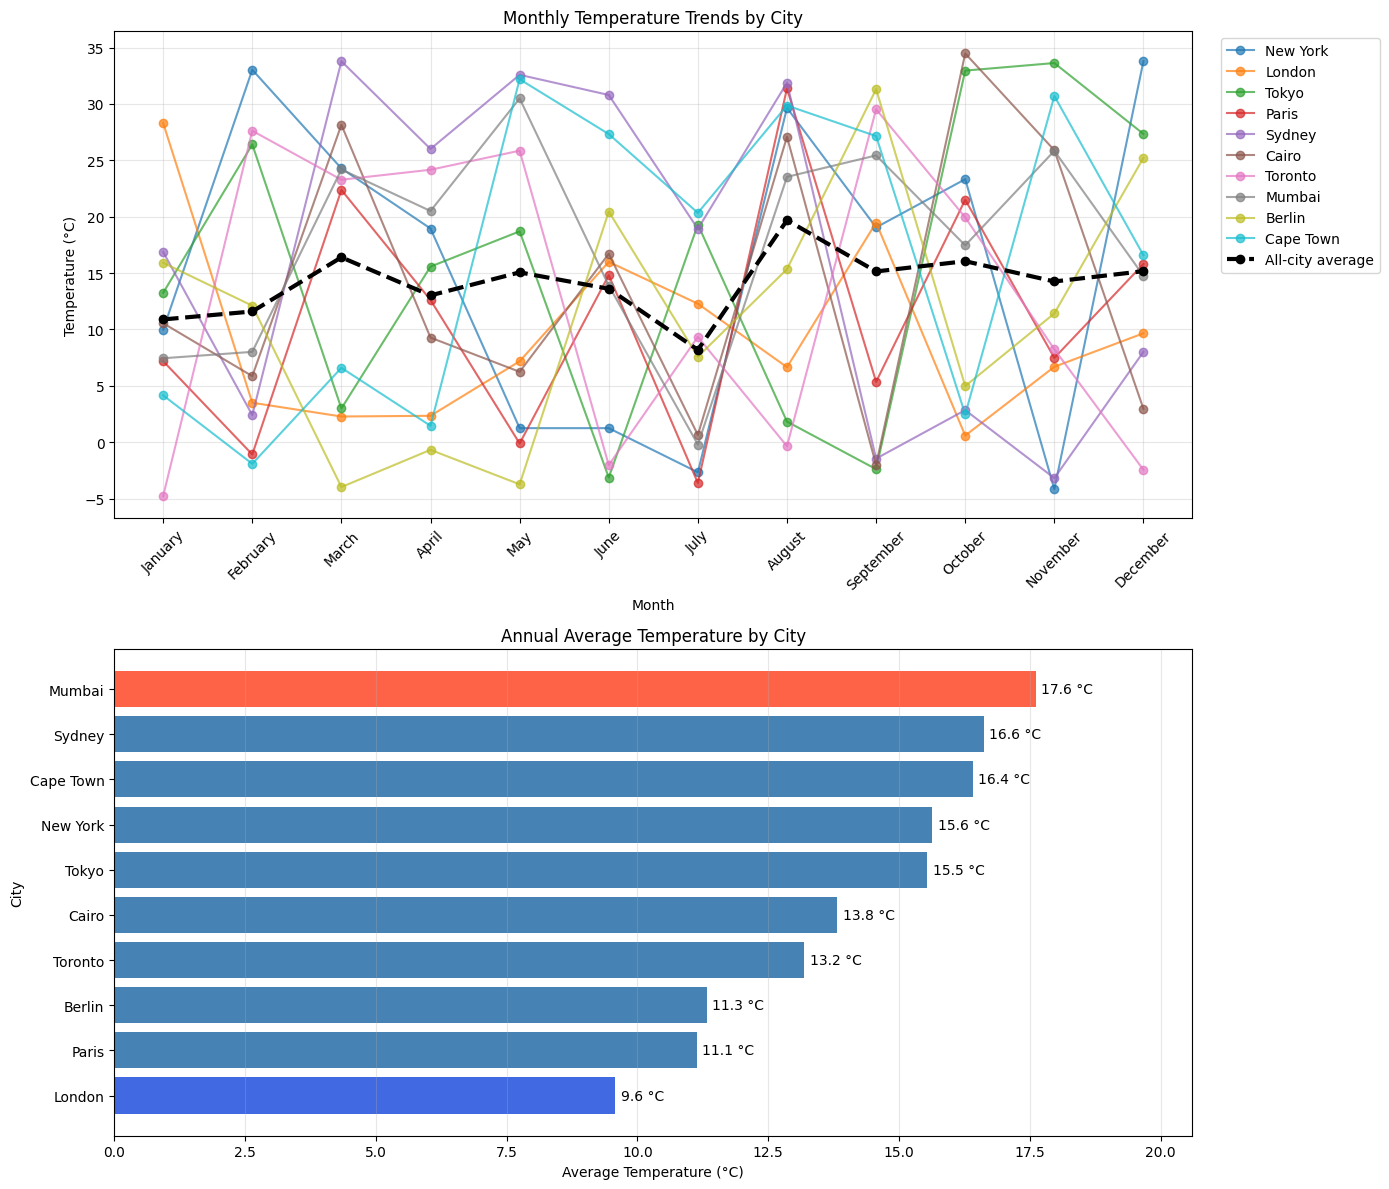

In [6]:
import matplotlib.pyplot as plt

# Calculate the average temperature for each month across all cities.
monthly_average_temperature = temperature_df.mean(axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Plot the monthly temperature trend for every city.
for city in temperature_df.index:
    ax1.plot(
        months,
        temperature_df.loc[city],
        marker='o',
        linewidth=1.5,
        alpha=0.7,
        label=city
    )

# Emphasize the overall monthly average.
ax1.plot(
    months,
    monthly_average_temperature,
    color='black',
    linestyle='--',
    marker='o',
    linewidth=3,
    label='All-city average'
)
ax1.set_title('Monthly Temperature Trends by City')
ax1.set_xlabel('Month')
ax1.set_ylabel('Temperature (°C)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(alpha=0.3)
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Compare annual averages and highlight the highest and lowest cities.
annual_sorted = annual_average_temperature.sort_values()
bar_colors = [
    'royalblue' if city == annual_sorted.index[0]
    else 'tomato' if city == annual_sorted.index[-1]
    else 'steelblue'
    for city in annual_sorted.index
]

bars = ax2.barh(annual_sorted.index, annual_sorted.values, color=bar_colors)
ax2.bar_label(bars, labels=[f'{value:.1f} °C' for value in annual_sorted], padding=4)
ax2.set_title('Annual Average Temperature by City')
ax2.set_xlabel('Average Temperature (°C)')
ax2.set_ylabel('City')
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim(0, annual_sorted.max() + 3)

fig.tight_layout()
plt.show()


## 4. Summary Report

- **Mumbai** has the highest annual average temperature at **17.6°C**, while **London** has the lowest at **9.6°C**.
- Across all cities, **August** is the warmest month on average at **19.7°C**, and **July** is the coolest at **8.2°C**.
- The highest individual value is **34.5°C** in Cairo during October, while the lowest is **−4.8°C** in Toronto during January.
- The chart contains noticeable month-to-month fluctuations. Because the data was generated randomly from a uniform distribution, these changes are synthetic and should not be interpreted as real seasonal climate patterns.
